In [1]:
%load_ext autoreload
%autoreload 2
%load_ext dotenv
%dotenv

In [2]:
import os
import sys

from nb2p import database, dgraph, astparse
from nb2p.notebook import Notebook

In [3]:
DATASET_NAME = "distilkaggle"

In [5]:
from nb2p.config import dirs

DIRS = dirs(DATASET_NAME)
DIRS.makedirs()

making dirs: /ssd/haotian/scs/distilkaggle/processed-unixcoder-ast
making dirs: /ssd/haotian/scs/distilkaggle
making dirs: /ssd/haotian/scs/distilkaggle/processed-unixcoder-full
making dirs: /ssd/haotian/scs/distilkaggle/dfgtree
making dirs: /ssd/haotian/scs/distilkaggle/processed-unixcoder-eda
making dirs: /ssd/haotian/scs/distilkaggle/logs/full
making dirs: /ssd/haotian/scs/distilkaggle/models/full
making dirs: /ssd/haotian/scs/distilkaggle/ipynb


## Step 3: Linking

In [6]:
db, client = database.connect(dataset_name=DATASET_NAME, verbose=True)

Pinged to database nb2p-dk. You successfully connected to MongoDB!


In [7]:
parser, lang = astparse.parser()

In [36]:
cursor = database.get_notebooks(
    db,
    {
        "prompted": True,
        "segment_ends.3": {"$exists": True},
        "n_ast_children_of_segments": {"$lte": 256},
    },
    include_segments=True,
)
for _ in range(50):
    cursor.next()
a_notebook_data = cursor.next()

a_notebook = Notebook.from_db_result_encoding(a_notebook_data)
a_notebook_fuzzed = Notebook.from_segment_ends_ast([1, 3, 5, 7, 8], a_notebook)
print(a_notebook.segment_ends_ast, a_notebook_fuzzed.segment_ends_ast)
a_notebook_fuzzed.pretty_print_segments()

[1, 5, 14, 17, 21, 26, 35, 41, 47, 58, 61, 63] [1, 3, 5, 7, 8, 60]
0	%matplotlib inline
	%matplotlib inline

1	
	src = pd.read_csv("../input/Salaries.csv", low_memory=False)
	src.describe()

2	
	en_stopwords = stopwords.words('english')
	src2014 = src[src["Year"]==2014]

3	
	job_titles = src2014["JobTitle"]
	unique_job_titles = job_titles.unique()

4	
	print("Job titles: ", job_titles.count(), " unique job titles ", len(unique_job_titles))

5	
	tokenized_titles = list(filter(None, [list(tokenize(title)) for title in unique_job_titles]))
	lengths = list(map(len, tokenized_titles))
	pd.DataFrame({"number or keywords per title": lengths}).hist();
	tokenized_title = tokenized_titles[0]
	print("original: ", tokenized_title)
	print("keywords: ", list(keywords_for_title(tokenized_title)))
	keywords_stats = Counter()
	for title in tokenized_titles:
	    for keyword in keywords_for_title(title):
	        keywords_stats[keyword] += 1
	print("distinct keywords: ", len(keywords_stats))
	keywords_s

In [37]:
a_notebook.pretty_print_segments()

0	%matplotlib inline

1	%matplotlib inline
	src = pd.read_csv("../input/Salaries.csv", low_memory=False)
	src.describe()

2	en_stopwords = stopwords.words('english')
	src2014 = src[src["Year"]==2014]
	job_titles = src2014["JobTitle"]
	unique_job_titles = job_titles.unique()
	print("Job titles: ", job_titles.count(), " unique job titles ", len(unique_job_titles))
	tokenized_titles = list(filter(None, [list(tokenize(title)) for title in unique_job_titles]))
	lengths = list(map(len, tokenized_titles))
	pd.DataFrame({"number or keywords per title": lengths}).hist();

3	tokenized_title = tokenized_titles[0]
	print("original: ", tokenized_title)
	print("keywords: ", list(keywords_for_title(tokenized_title)))

4	keywords_stats = Counter()
	for title in tokenized_titles:
	    for keyword in keywords_for_title(title):
	        keywords_stats[keyword] += 1
	print("distinct keywords: ", len(keywords_stats))
	keywords_stats.most_common(15)

5	salaries = Counter()
	counts = Counter()
	min_salaries 

In [38]:
G = dgraph.DGraph(a_notebook, parser)

In [39]:
G.vardeps

[{'type': 'def',
  'def_type': 'variable',
  'node': <Node type=identifier, start_point=(2, 0), end_point=(2, 3)>,
  'content': 'src',
  'line': 2,
  'period': (Point(row=2, column=0), Point(row=2, column=3))},
 {'type': 'ref',
  'source': <Node type=identifier, start_point=(3, 0), end_point=(3, 3)>,
  'target': {'type': 'def',
   'def_type': 'variable',
   'node': <Node type=identifier, start_point=(2, 0), end_point=(2, 3)>,
   'content': 'src',
   'line': 2,
   'period': (Point(row=2, column=0), Point(row=2, column=3))},
  'content': 'src',
  'line_source': 3,
  'line_target': 2,
  'period': (Point(row=3, column=0), Point(row=3, column=3))},
 {'type': 'def',
  'def_type': 'variable',
  'node': <Node type=identifier, start_point=(4, 0), end_point=(4, 12)>,
  'content': 'en_stopwords',
  'line': 4,
  'period': (Point(row=4, column=0), Point(row=4, column=12))},
 {'type': 'def',
  'def_type': 'variable',
  'node': <Node type=identifier, start_point=(5, 0), end_point=(5, 7)>,
  'content'

In [40]:
import networkx as nx

fuzzed = G.get_nx_multigraph()
fuzzed.add_node(8)
fuzzed.add_node(9)
fuzzed.add_edge(8, 9)
nx.graph_edit_distance(G.get_nx_multigraph(), fuzzed)

1.0

In [41]:
G.density

0.1590909090909091

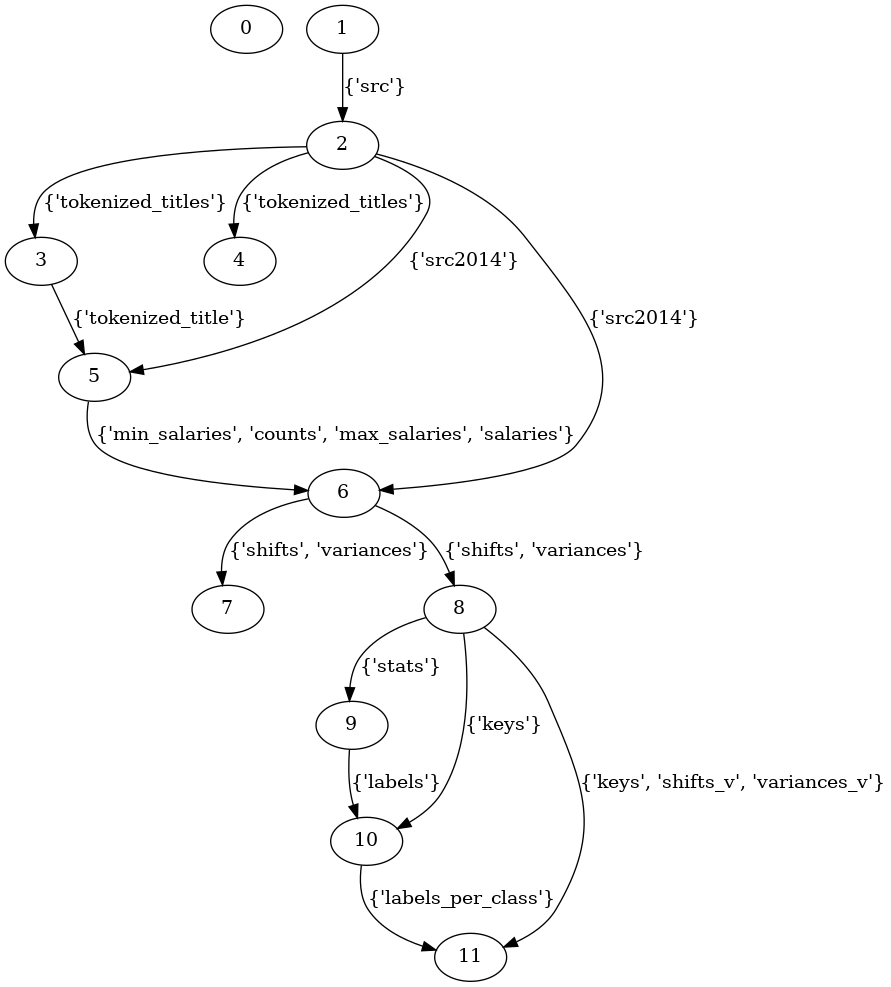

In [44]:
G.display_pydot()

In [28]:
# G.save_pydot("cc-sample-wocode.pdf")

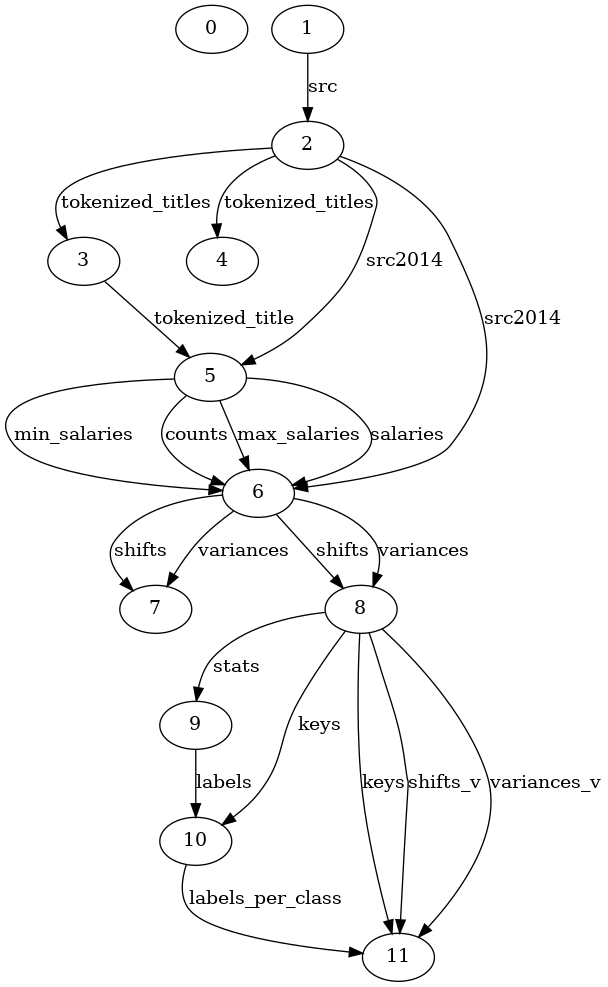

In [43]:
G.display_pydot_multigraph()

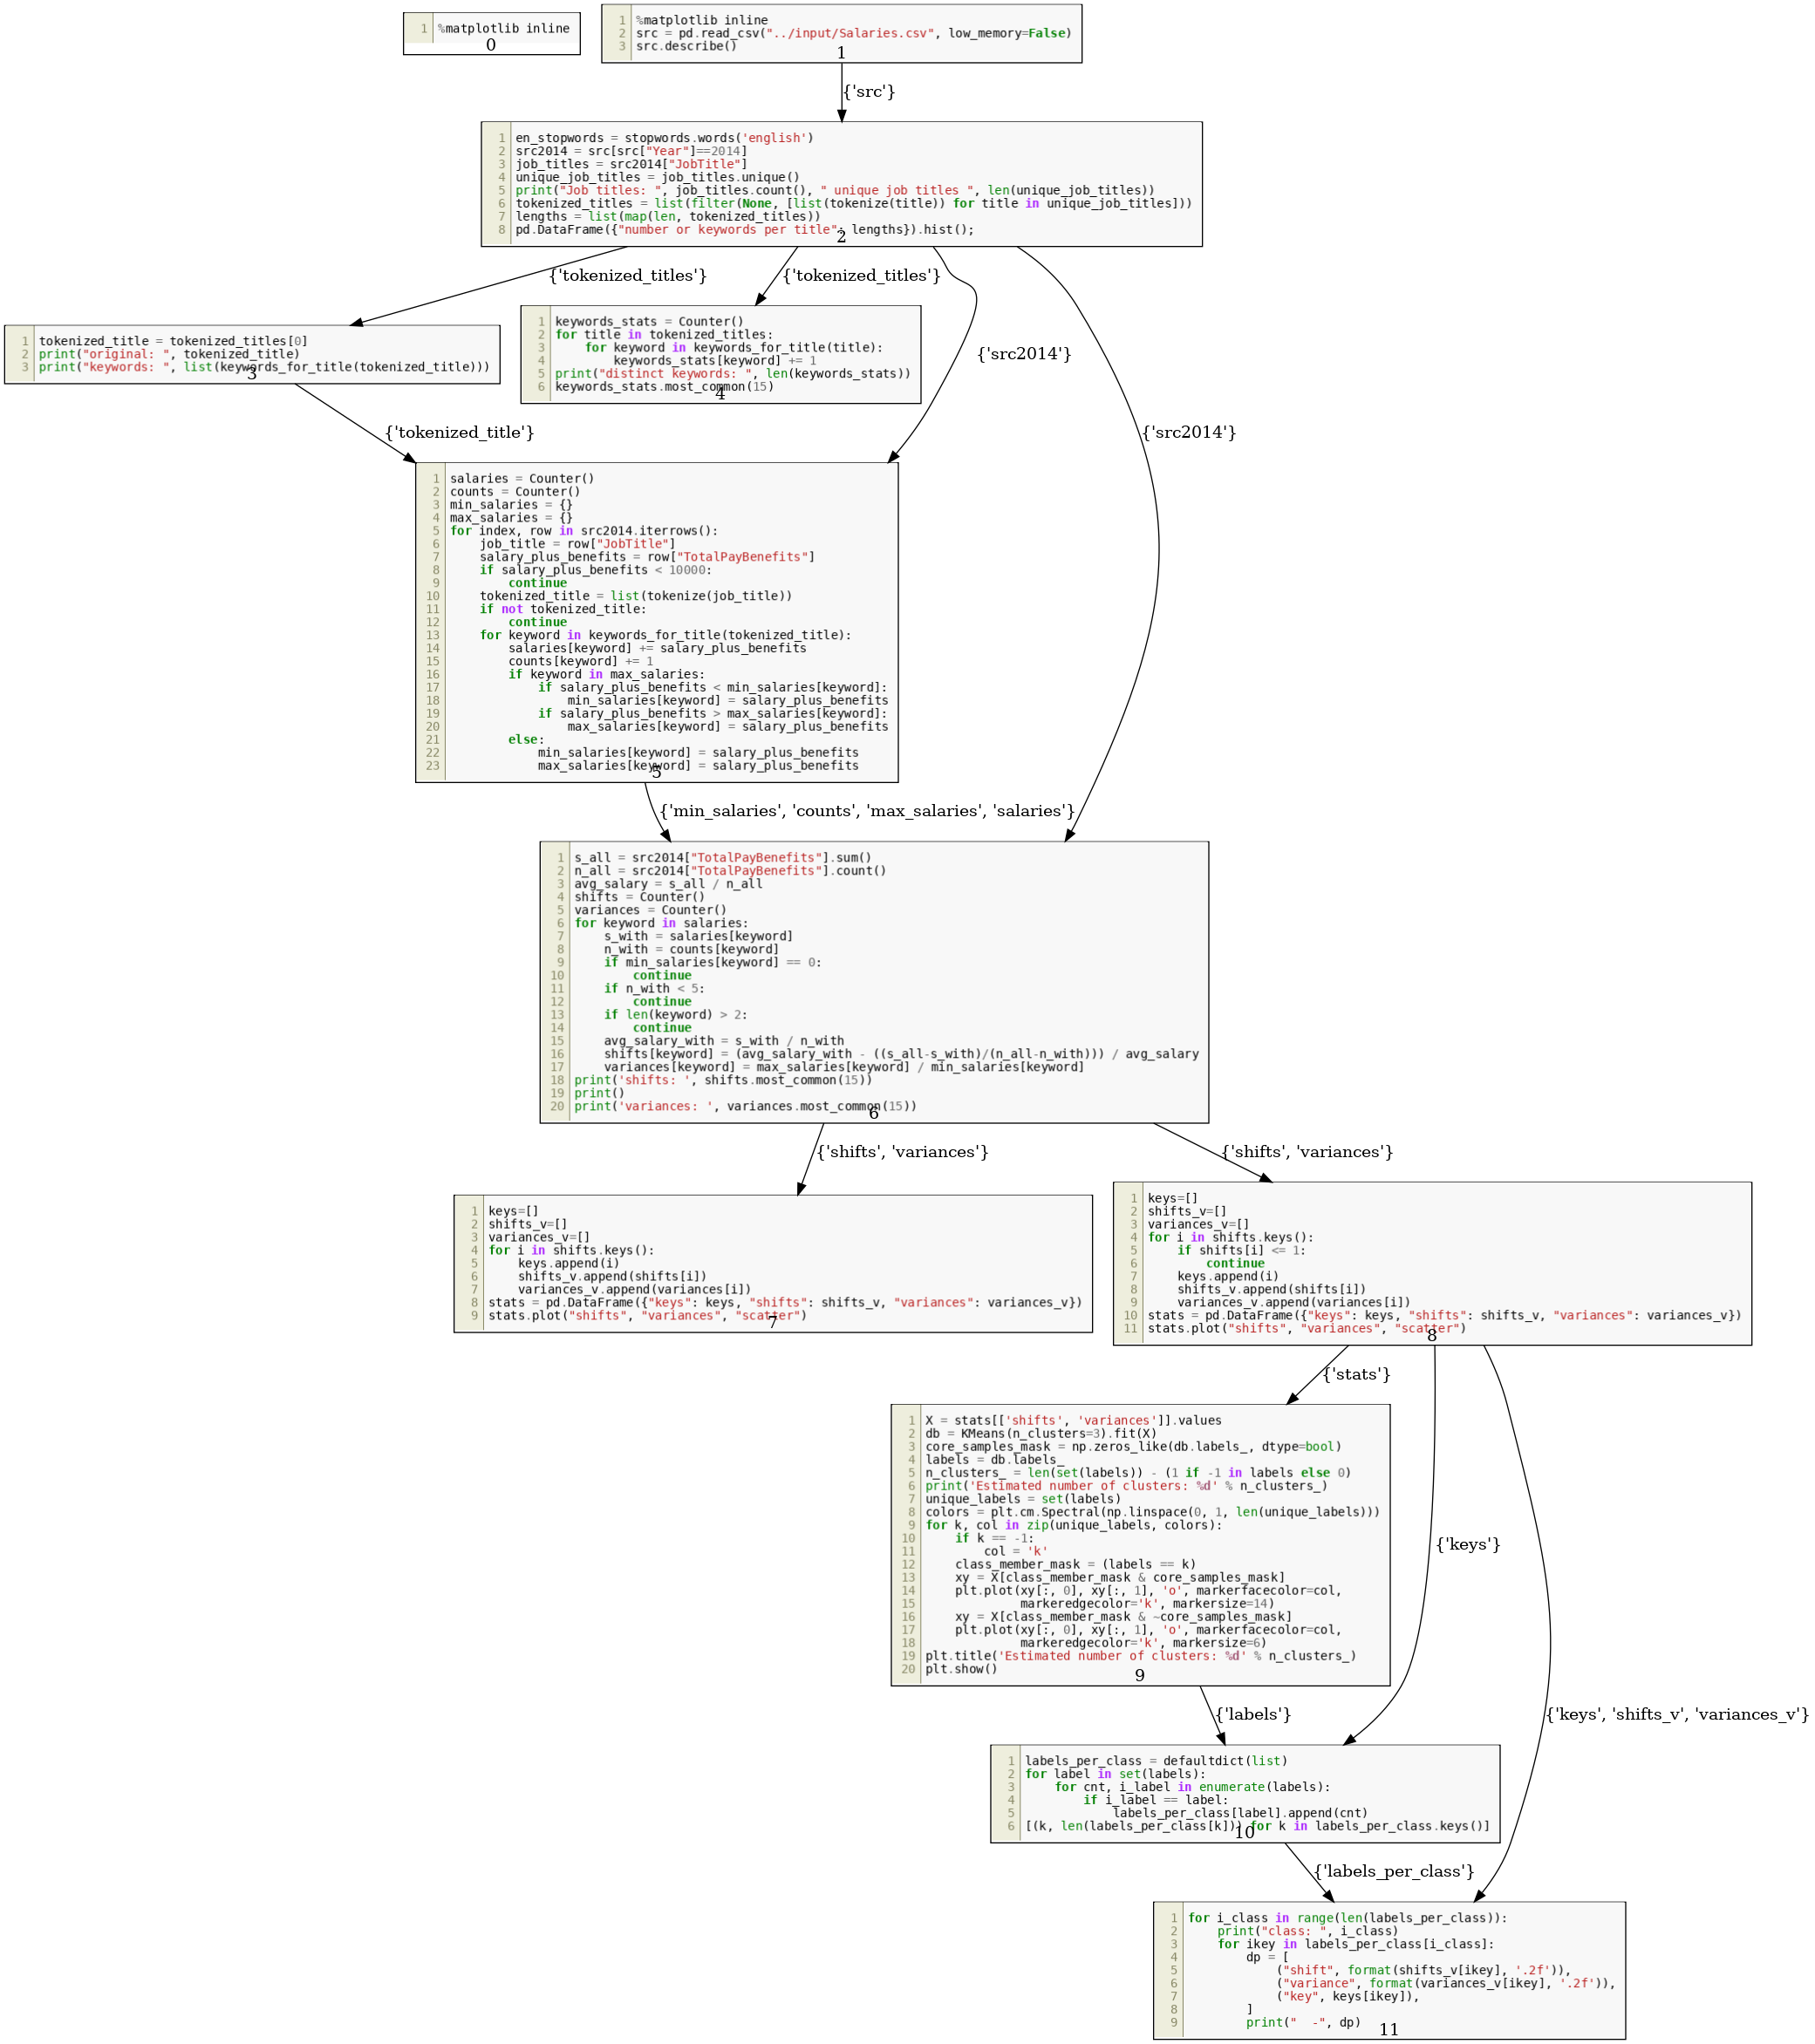

In [45]:
G.display_pydot(with_code=True)

In [19]:
# G.save_pydot("cc-sample-wcode.pdf", with_code=True)

In [46]:
print(list(G.get_nx().nodes))
print(list(G.get_nx().edges))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
[(1, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 5), (5, 6), (6, 7), (6, 8), (8, 9), (8, 10), (8, 11), (9, 10), (10, 11)]


In [47]:
import networkx as nx

nx.get_edge_attributes(G.get_nx(), "label")

{(1, 2): {'src'},
 (2, 3): {'tokenized_titles'},
 (2, 4): {'tokenized_titles'},
 (2, 5): {'src2014'},
 (2, 6): {'src2014'},
 (3, 5): {'tokenized_title'},
 (5, 6): {'counts', 'max_salaries', 'min_salaries', 'salaries'},
 (6, 7): {'shifts', 'variances'},
 (6, 8): {'shifts', 'variances'},
 (8, 9): {'stats'},
 (8, 10): {'keys'},
 (8, 11): {'keys', 'shifts_v', 'variances_v'},
 (9, 10): {'labels'},
 (10, 11): {'labels_per_class'}}

In [48]:
G.get_dagre_data()

{'nodes': [{'id': '0', 'label': '0'},
  {'id': '1', 'label': '1'},
  {'id': '2', 'label': '2'},
  {'id': '3', 'label': '3'},
  {'id': '4', 'label': '4'},
  {'id': '5', 'label': '5'},
  {'id': '6', 'label': '6'},
  {'id': '7', 'label': '7'},
  {'id': '8', 'label': '8'},
  {'id': '9', 'label': '9'},
  {'id': '10', 'label': '10'},
  {'id': '11', 'label': '11'}],
 'links': [{'source': '1', 'target': '2', 'label': "{'src'}"},
  {'source': '2', 'target': '3', 'label': "{'tokenized_titles'}"},
  {'source': '2', 'target': '4', 'label': "{'tokenized_titles'}"},
  {'source': '2', 'target': '5', 'label': "{'src2014'}"},
  {'source': '2', 'target': '6', 'label': "{'src2014'}"},
  {'source': '3', 'target': '5', 'label': "{'tokenized_title'}"},
  {'source': '5',
   'target': '6',
   'label': "{'min_salaries', 'counts', 'max_salaries', 'salaries'}"},
  {'source': '6', 'target': '7', 'label': "{'shifts', 'variances'}"},
  {'source': '6', 'target': '8', 'label': "{'shifts', 'variances'}"},
  {'source':